# Take-Home: Data Understanding — Fraud Detection
## CRISP-DM Phase 2
All required Python code is provided. **You are not assessed on writing code.** Run each cell and write your evidence-based answers in Markdown.
Do **not** clean, delete, impute, encode, transform or model the data. Continue from your Week 1 Business Understanding and explicitly use the feedback you received.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns",None)
df=pd.read_csv("fraud_detection.csv")
df.head()

,transaction_id,channel,country,amount_eur,hour_of_day,previous_transactions_24h,fraud_flag
0,1,Online,IT,83.95,13,1,0
1,2,Online,FR,10.12,2,1,0
2,3,Mobile,NL,26.96,10,1,0
3,4,Online,IT,44.80,13,1,0
4,5,POS,BE,51.58,5,1,0


## 1. Understand the dataset
Answer: What does one row represent? How many observations/variables are there? What is the identifier/business key? What is the main outcome? Which variables matter most to your business problem?

In [5]:
print("Shape:",df.shape)
df.info()
display(df.nunique(dropna=False).sort_values())

Shape: (2000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             2000 non-null   int64  
 1   channel                    2000 non-null   str    
 2   country                    2000 non-null   str    
 3   amount_eur                 2000 non-null   float64
 4   hour_of_day                2000 non-null   int64  
 5   previous_transactions_24h  2000 non-null   int64  
 6   fraud_flag                 2000 non-null   int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 109.5 KB


fraud_flag                      2
channel                         3
country                         6
previous_transactions_24h       7
hour_of_day                    24
amount_eur                   1777
transaction_id               2000
dtype: int64

### Your answer
**One row represents:** one transaction 
**Dimensions:** 2000 rows and 7 columns 
**Identifier/business key:** transaction_id  
**Main outcome:** fraud_flag
**Most relevant variables and why:** channel, country and amount_eur. They descripe the transaction

## 2. Data quality — observe, do not fix
Identify missing values, duplicates, unexpected types/categories and implausible ranges. Explain why any issue could matter.

In [14]:
quality=pd.DataFrame({"type":df.dtypes.astype(str),"missing":df.isna().sum(),"unique":df.nunique(dropna=False)})
display(quality)
print("Exact duplicates:",df.duplicated().sum())
for col in df.select_dtypes(exclude="number").columns:
 print("\n",col); print(df[col].value_counts(dropna=False).head(20))

,type,missing,unique
transaction_id,int64,0,2000
channel,str,0,3
country,str,0,6
amount_eur,float64,0,1777
hour_of_day,int64,0,24
previous_transactions_24h,int64,0,7
fraud_flag,int64,0,2


Exact duplicates: 0

 channel
channel
Mobile    711
POS       659
Online    630
Name: count, dtype: int64

 country
country
BE    359
FR    344
IT    340
DE    327
NL    320
ES    310
Name: count, dtype: int64


### Data-quality findings
| Observation/issue | Variable(s) | Evidence | Why it matters |
|---|---|---|---|
### Data-quality findings
| Observation/issue | Variable(s) | Evidence | Why it matters |
|---|---|---|---|
| No missing values | all columns |  0 for every column | The full dataset can be used; no rows need to be dropped or filled in later. |
| No exact duplicate rows | all columns | Exact duplicates: 0 | Each transaction is recorded once, so counts and fraud rates are not inflated by repeated rows. |
| `transaction_id` is the row counter | transaction_id | Values run from 1 to 2000 with no gaps or repeats | It carries no real business meaning and should not be used as a predictive feature, only as a lookup key. |
| Categories are limited but balanced | channel, country | `channel`: Mobile 711, POS 659, Online 630; `country`: BE 359, FR 344, IT 340, DE 327, NL 320, ES 310 | No category dominates or is too small to analyse, but the country list only covers 6 EU countries, so findings may not generalise further. |
| Fraud is a rare category | fraud_flag | Only 115 of 2,000 rows (5.75%) are fraud | This is a strong class imbalance, which matters later: a model that always predicts "no fraud" would already look 94.25% "accurate" while being useless. |

## 3. Summary statistics
Interpret important values rather than copying output. Give at least three observations and explain their business meaning.

In [7]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
channel,2000,3,Mobile,711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,2000,6,BE,359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_eur,2000.0,NaN,NaN,NaN,54.59786,74.688435,1.28,16.3375,32.415,61.7675,942.56
hour_of_day,2000.0,NaN,NaN,NaN,11.741,6.978486,0.0,6.0,12.0,18.0,23.0
previous_transactions_24h,2000.0,NaN,NaN,NaN,1.1675,1.073788,0.0,0.0,1.0,2.0,6.0
fraud_flag,2000.0,NaN,NaN,NaN,0.0575,0.232854,0.0,0.0,0.0,0.0,1.0


### Your interpretation
1. **Evidence:** `amount_eur` has a mean of €54.60 but a median of only €32.42, with a maximum of €942.56. **Business meaning:** The mean is pulled up by a small number of large transactions. Most payments are small everyday purchases, while a few large ones make the average look higher than what a typical customer pays.
2. **Evidence:** `fraud_flag` has a mean of 0.0575. **Business meaning:** Only 5.75% of transactions are fraud. This confirms fraud is rare, so the task is really about finding a small number of risky cases inside a much larger group of normal transactions.
3. **Evidence:** `previous_transactions_24h` has a mean of 1.17, a median of 1, and a maximum of 6. **Business meaning:** Most customers make very few transactions per day in this dataset. A sudden jump in this count could be a useful warning sign later, but on its own it does not vary enough here to separate fraud from normal activity.

## 4. Understand the main outcome: `fraud_flag`
Explain its distribution in plain business language. Is it balanced, rare, concentrated, or continuous? Why might this matter later? What context is needed before calling the result good/bad?

fraud_flag
0    1885
1     115
Name: count, dtype: int64
fraud_flag
0    94.25
1     5.75
Name: proportion, dtype: float64


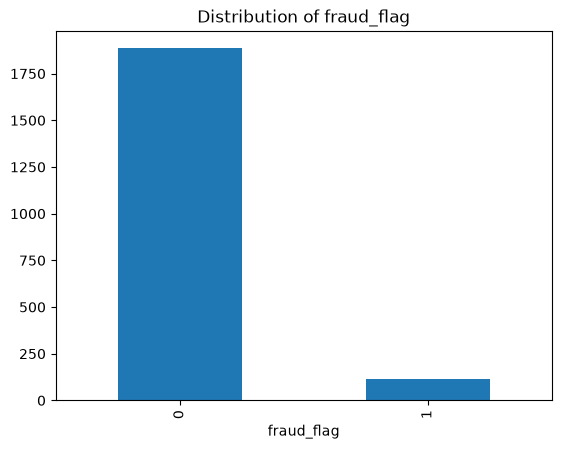

In [8]:
print(df["fraud_flag"].value_counts(dropna=False))
print((df["fraud_flag"].value_counts(normalize=True,dropna=False)*100).round(2))
df["fraud_flag"].value_counts(dropna=False).plot(kind="bar",title="Distribution of fraud_flag")
plt.show()

### Your outcome interpretation
`fraud_flag` is heavily imbalanced: 1,885 transactions are not fraud, and 115 are fraud. This is a rare outcome, not a balanced one, and it is concentrated in a small minority of cases rather than spread evenly.

This matters later because it will be easy for a model to reach high accuracy just by predicting "no fraud" for everything, without catching any real fraud at all. Before calling any future result "good" or "bad," we need business context: how many fraud cases does the current process already catch, what does one missed fraud case cost, and what does it cost to wrongly flag a genuine customer? Without that context, a headline accuracy or recall number cannot be judged on its own.

## 5. Visual exploration
For every chart write: **Evidence → Business interpretation → Caution**. An association does not prove causation.

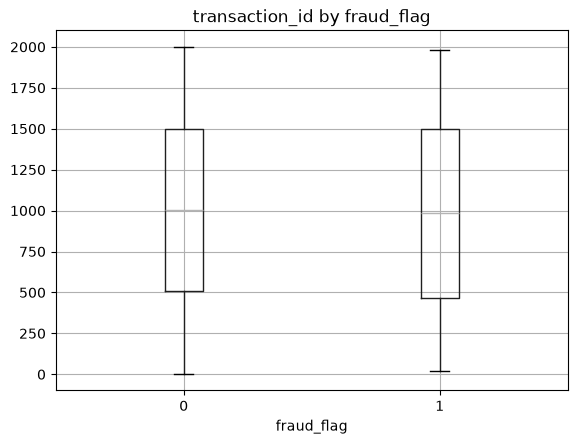

In [9]:
df.boxplot(column="transaction_id",by="fraud_flag"); plt.title("transaction_id by fraud_flag"); plt.suptitle(""); plt.show()

### Interpret `transaction_id`
**Evidence:** The fraud group (mean id ≈ 988, median 987) and the non-fraud group (mean id ≈ 1,001, median 1,002) look almost identical, with a similar spread (std ≈ 578 for both groups).
**Business interpretation:** `transaction_id` does not separate fraud from normal transactions
**Caution:** Any small difference between the groups here is just noise from row order, not a real pattern. This variable should not be interpreted or used as a predictor.

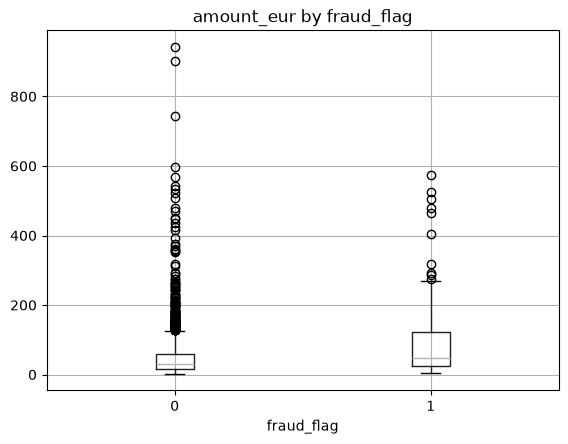

In [10]:
df.boxplot(column="amount_eur",by="fraud_flag"); plt.title("amount_eur by fraud_flag"); plt.suptitle(""); plt.show()

### Interpret `amount_eur`
**Evidence:** Fraud transactions have a mean amount of €99.44 (median €46.81), almost double the non-fraud mean of €51.86 (median €31.71). The 75th percentile for fraud (€122.96) is also much higher than for non-fraud (€59.99).
**Business interpretation:** Fraud transactions tend to involve noticeably larger amounts, so transaction size looks like a useful signal for flagging risky transactions.
**Caution:** The two groups still overlap a lot (the smallest fraud amount is only €5.25), so amount alone cannot reliably separate fraud from genuine large purchases. Using it by itself would also flag many honest high-value transactions, and this is an association in the data, not proof that a high amount causes fraud..

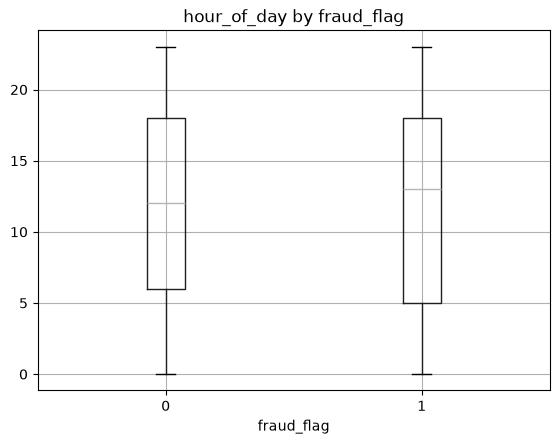

In [11]:
df.boxplot(column="hour_of_day",by="fraud_flag"); plt.title("hour_of_day by fraud_flag"); plt.suptitle(""); plt.show()

### Interpret `hour_of_day`
**Evidence:** The average hour is almost the same for fraud (12.30) and non-fraud (11.71) transactions, and the spread (std ≈ 7 for both) matches what you would expect if transactions were spread evenly across all 24 hours.
**Business interpretation:** Time of day does not show a clear pattern here. fraud does not obviously cluster at night or at any particular time in this dataset.
**Caution:** This goes against the common assumption that fraud happens mostly at odd hours. We should not build a "night-time = risky" rule from this data, since the evidence does not support it.

,channel,observations,outcome
0,Mobile,711,0.052039
1,Online,630,0.079365
2,POS,659,0.042489


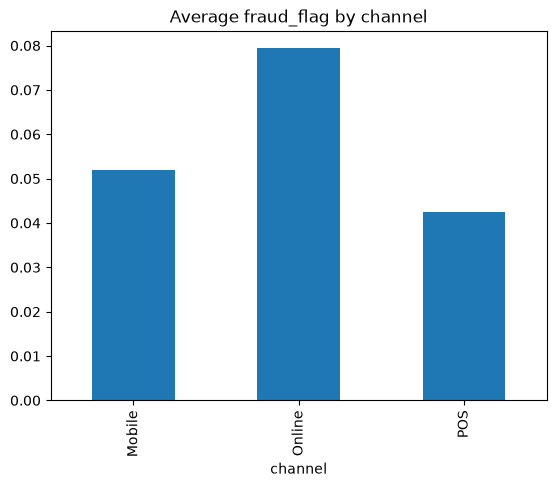

In [12]:
s=df.groupby("channel",dropna=False).agg(observations=("fraud_flag","size"),outcome=("fraud_flag","mean")).reset_index()
display(s)
s.plot(x="channel",y="outcome",kind="bar",legend=False); plt.title("Average fraud_flag by channel"); plt.show()

### Interpret `channel`
**Evidence:** The fraud rate is 7.94% for Online transactions, versus 5.20% for Mobile and 4.25% for POS. Online's fraud rate is nearly double that of POS.
**Business interpretation:** Online transactions look meaningfully riskier than in-person (POS) payments, which fits the idea that in-person payments have extra physical checks that online payments lack.
**Caution:** The group sizes are moderate (630–711 each) and the underlying fraud counts are still small (roughly 25–50 fraud cases per channel), so this difference should be confirmed with more data before it drives a policy change. It is also an association. the channel itself does not cause fraud, it may just correlate with weaker checks.

,country,observations,outcome
0,BE,359,0.069638
1,DE,327,0.051988
2,ES,310,0.054839
3,FR,344,0.063953
4,IT,340,0.041176
5,NL,320,0.062500


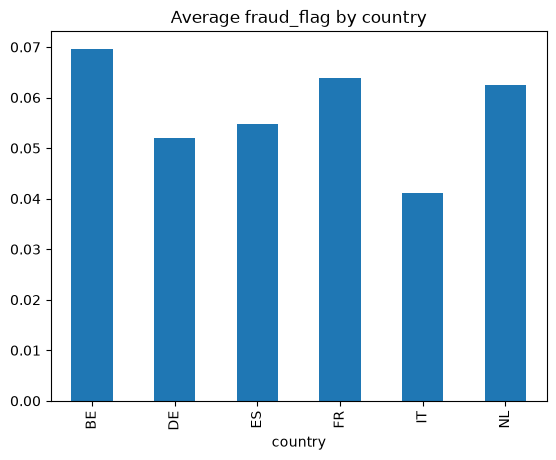

In [13]:
s=df.groupby("country",dropna=False).agg(observations=("fraud_flag","size"),outcome=("fraud_flag","mean")).reset_index()
display(s)
s.plot(x="country",y="outcome",kind="bar",legend=False); plt.title("Average fraud_flag by country"); plt.show()

### Interpret `country`
**Evidence:** Fraud rates by country range from 4.12% (Italy) to 6.96% (Belgium), with France, the Netherlands, Spain and Germany in between (5.2%–6.4%).
**Business interpretation:** The differences between countries are much smaller than the channel differences, and there is no extreme outlier country.
**Caution:** With only 310–359 transactions and roughly 13–25 fraud cases per country, these percentages rest on small counts and can shift a lot with just a few more or fewer fraud cases. I would not treat country as a strong signal without a larger sample.

## 6. Three key insights
Select your three most important findings. For each provide evidence and explain its relevance to the business problem.

1. **Fraud is rare and imbalanced (5.75% of transactions).** This is the most important finding for later modelling: accuracy alone will be a misleading success metric. We will need to focus on recall and false-positive rate, and agree in advance on how many false alarms the business can accept for each fraud case caught.
2. **Fraud transactions involve larger amounts on average (€99.44 vs €51.86), but the ranges overlap heavily.** Amount is a useful but not sufficient signal — a good detection approach will need to combine it with other variables rather than rely on a simple amount threshold.
3. **Online transactions have a clearly higher fraud rate (7.94%) than POS (4.25%).** This points to channel as a meaningful risk factor and suggests extra checks (such as step-up verification) could be targeted at online payments specifically, rather than applied evenly everywhere.

## 7. Revisit Week 1 Business Understanding
1. What feedback did you receive?
2. What did you change because of it?
3. Which assumptions are supported by this data?
4. Which are challenged or remain uncertain?
5. Should your business problem, objective, success criteria or stakeholder perspective be refined? Explain.

### Your reflection
---


## 8. Limitations and next questions
What can this dataset not tell you? What important information is missing? What additional data would help? What questions should carry forward?

### Your answer
This dataset cannot tell us *why* a transaction is fraud, only that it was flagged as one. there is no reason code, no investigation outcome, and no way to check how reliable the `fraud_flag` label itself is.

Important information is missing: there is no customer or account identifier (so we cannot see a customer's full history, only their transaction count in the last 24 hours), no device, IP, or authentication data, no full date-time stamp beyond the hour of day (so we cannot see trends over days, weeks, or seasons), and no cost information (what a missed fraud case or a false alarm actually costs the business).

Additional data that would help: a customer or account ID to build behavioural history, device and location signals, the authentication method used, a full date-time stamp, and the outcome of any manual investigation.

Questions to carry forward: how reliable is the `fraud_flag` label itself? Is `country` the customer's home country or the transaction location? Why exactly is the online channel riskier? And what is the current cost of a missed fraud case compared to a wrongly blocked genuine customer?

# Submission check
- [ ] All supplied code cells run successfully.
- [ ] All Markdown prompts are answered in my own words.
- [ ] I interpret evidence rather than copy output.
- [ ] I link findings to my Business Understanding.
- [ ] I explicitly reflect on Week 1 feedback.
- [ ] I distinguish association from causation.
- [ ] I identify quality concerns but do not perform Data Preparation.
- [ ] I submit the `.ipynb`.

**Deadline: 23 September 2026 at 13:00 (CET).**